# 6. Demographic Alignment Analysis

**Goal**: Measure which demographic groups (gender, income, social class) are most/least aligned with how the EU Parliament actually voted.

**Method**:
1. Join `survey_answer_alignments` (Supabase) with `volume_b_answer_distributions.csv` on `(question_id, file_name, answer_label)`
2. Compute per-question alignment scores by demographic group
3. Aggregate across all questions
4. Statistical tests (chi-squared, Cramer's V, pairwise z-tests)

In [3]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from scipy.stats import chi2_contingency
from supabase import create_client

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted")

load_dotenv()
supabase = create_client(os.getenv("SUPABASE_URL"), os.getenv("SUPABASE_KEY"))
print("Supabase connected.")

Supabase connected.


## 2. Load alignments from Supabase

In [4]:
# Load survey_answer_alignments
alignments_resp = supabase.table("survey_answer_alignments").select("*").execute()
df_alignments = pd.DataFrame(alignments_resp.data)
print(f"Alignments loaded: {len(df_alignments)} rows")
print(f"Columns: {list(df_alignments.columns)}")
display(df_alignments.head())

# Load survey_vote_matches for context (question text, vote info)
matches_resp = (
    supabase.table("survey_vote_matches")
    .select(
        "match_id, question_id, question_clean, survey_file, vote_id, vote_summary_clean, vote_date"
    )
    .eq("admin_validated", True)
    .execute()
)
df_matches = pd.DataFrame(matches_resp.data)
print(f"\nAccepted matches loaded: {len(df_matches)} rows")
display(df_matches.head())

Alignments loaded: 178 rows
Columns: ['match_id', 'answer_label', 'alignment', 'survey_file', 'question_id', 'vote_id', 'created_at']


,match_id,answer_label,alignment,survey_file,question_id,vote_id,created_at
0,T13_153304_0,More decision-making at European level,aligned,ebs_509_volume_B.xlsx,T13,153304,2026-03-15T08:19:32.290181+00:00
1,T13_153304_0,Less decision-making at European level,opposed,ebs_509_volume_B.xlsx,T13,153304,2026-03-15T08:19:32.290181+00:00
2,T13_153304_0,No change is needed/as it is now,neutral,ebs_509_volume_B.xlsx,T13,153304,2026-03-15T08:19:32.290181+00:00
3,T13_153304_0,Don't know,unknown,ebs_509_volume_B.xlsx,T13,153304,2026-03-15T08:19:32.290181+00:00
4,QA23_154611_1,Les fruits et légumes frais,unrelated,Lien_vers_CAP_2022_eb_sp_520_volume_B.xlsx,QA23,154611,2026-03-15T08:23:24.91182+00:00



Accepted matches loaded: 97 rows


,match_id,question_id,question_clean,survey_file,vote_id,vote_summary_clean,vote_date
0,QE3_9_157788_4,QE3_9,To what extent do you agree or disagree that t...,Lien_vers_eb98_volume_B.xlsx,157788,The European Parliament voted to increase rene...,2023-09-12 12:16:00
1,T13_153304_0,T13,Should more or less decision-making for protec...,ebs_509_volume_B.xlsx,153304,The European Parliament voted to approve a pla...,2023-03-14 12:15:00
2,T68_157227_7,T68,To what extent do you agree that the EU should...,ebs_500_volume_B.xlsx,157227,Parliament approved recommendations to enhance...,2023-07-12 13:20:00
3,T13_148875_9,T13,Should more or less decision-making for protec...,ebs_509_volume_B.xlsx,148875,"The European Parliament, in a vote of 468 to 5...",2022-10-06 12:23:00
4,T7_164961_6,T7,Do you agree or disagree that the EU should st...,ebs_512_volume_B.xlsx,164961,"The European Parliament approved, by a signifi...",2024-02-29 12:04:00


## 3. Load & filter CSV distributions

In [6]:
CSV_PATH = "./data/surveys/volume_b_answer_distributions.csv"
df_csv = pd.read_csv(CSV_PATH)
print(f"CSV loaded: {len(df_csv)} rows")
print(f"Columns: {list(df_csv.columns)}")
print(f"\nDemographic types: {df_csv['demographic_type'].unique()}")
print(f"is_summary values: {df_csv['is_summary'].unique()}")

# Filter: non-summary, target demographics only
TARGET_DEMOGRAPHICS = ["gender", "income_difficulty", "class_belonging"]
df_demo = df_csv[
    (df_csv["is_summary"] == False)
    & (df_csv["demographic_type"].isin(TARGET_DEMOGRAPHICS))
].copy()
print(f"\nFiltered to target demographics: {len(df_demo)} rows")
print(f"Demographic breakdown:")
for dt in TARGET_DEMOGRAPHICS:
    subset = df_demo[df_demo["demographic_type"] == dt]
    print(
        f"  {dt}: {len(subset)} rows, values: {sorted(subset['demographic_value'].unique())}"
    )

CSV loaded: 16460 rows
Columns: ['sheet_id', 'file_name', 'question_clean', 'answer_label', 'is_summary', 'demographic_type', 'demographic_value', 'count', 'pct', 'total_base']

Demographic types: <ArrowStringArray>
['total', 'gender', 'income_difficulty', 'occupation', 'class_belonging']
Length: 5, dtype: str
is_summary values: [False  True]

Filtered to target demographics: 6662 rows
Demographic breakdown:
  gender: 1666 rows, values: ['female', 'male']
  income_difficulty: 1911 rows, values: ['medium', 'poor', 'rich']
  class_belonging: 3085 rows, values: ['lower_middle', 'middle', 'upper', 'upper_middle', 'working_class']


## 4. Join datasets

In [7]:
# Normalize join keys
df_alignments["question_id"] = df_alignments["question_id"].astype(str).str.strip()
df_alignments["survey_file"] = df_alignments["survey_file"].astype(str).str.strip()
df_alignments["answer_label"] = df_alignments["answer_label"].astype(str).str.strip()

df_demo["sheet_id"] = df_demo["sheet_id"].astype(str).str.strip()
df_demo["file_name"] = df_demo["file_name"].astype(str).str.strip()
df_demo["answer_label"] = df_demo["answer_label"].astype(str).str.strip()

# Join: alignments <-> demographic distributions
df_joined = df_demo.merge(
    df_alignments[
        ["question_id", "survey_file", "answer_label", "alignment", "match_id"]
    ],
    left_on=["sheet_id", "file_name", "answer_label"],
    right_on=["question_id", "survey_file", "answer_label"],
    how="inner",
)

print(f"Joined rows: {len(df_joined)}")
print(f"Unique questions in join: {df_joined['question_id'].nunique()}")
print(f"Unique match_ids in join: {df_joined['match_id'].nunique()}")
print(f"Alignment distribution in join:")
print(df_joined["alignment"].value_counts())

if len(df_joined) == 0:
    print("\n⚠️ WARNING: Empty join! Check key normalization.")
    # Debug: show sample keys from each side
    print("\nAlignment keys (first 5):")
    print(df_alignments[["question_id", "survey_file", "answer_label"]].head())
    print("\nCSV keys (first 5):")
    print(df_demo[["sheet_id", "file_name", "answer_label"]].head())
else:
    display(df_joined.head())

Joined rows: 1570
Unique questions in join: 20
Unique match_ids in join: 29
Alignment distribution in join:
alignment
unrelated    470
aligned      386
opposed      366
unknown      288
neutral       60
Name: count, dtype: int64


,sheet_id,file_name,question_clean,answer_label,is_summary,demographic_type,demographic_value,count,pct,total_base,question_id,survey_file,alignment,match_id
0,QA23,Lien_vers_CAP_2022_eb_sp_520_volume_B.xlsx,"Which products, considering children's need fo...",Les fruits et légumes frais,False,gender,male,10404.0,82.0,12680.0,QA23,Lien_vers_CAP_2022_eb_sp_520_volume_B.xlsx,unrelated,QA23_154611_1
1,QA23,Lien_vers_CAP_2022_eb_sp_520_volume_B.xlsx,"Which products, considering children's need fo...",Les fruits et légumes frais,False,gender,female,11731.0,85.0,13813.0,QA23,Lien_vers_CAP_2022_eb_sp_520_volume_B.xlsx,unrelated,QA23_154611_1
2,QA23,Lien_vers_CAP_2022_eb_sp_520_volume_B.xlsx,"Which products, considering children's need fo...",Les fruits et légumes frais,False,income_difficulty,poor,1208.0,75.0,1600.0,QA23,Lien_vers_CAP_2022_eb_sp_520_volume_B.xlsx,unrelated,QA23_154611_1
3,QA23,Lien_vers_CAP_2022_eb_sp_520_volume_B.xlsx,"Which products, considering children's need fo...",Les fruits et légumes frais,False,income_difficulty,medium,5014.0,79.0,6346.0,QA23,Lien_vers_CAP_2022_eb_sp_520_volume_B.xlsx,unrelated,QA23_154611_1
4,QA23,Lien_vers_CAP_2022_eb_sp_520_volume_B.xlsx,"Which products, considering children's need fo...",Les fruits et légumes frais,False,income_difficulty,rich,15697.0,86.0,18294.0,QA23,Lien_vers_CAP_2022_eb_sp_520_volume_B.xlsx,unrelated,QA23_154611_1


## 5. Compute per-question alignment scores by demographic group

In [8]:
# Ensure count is numeric
df_joined["count"] = pd.to_numeric(df_joined["count"], errors="coerce").fillna(0)
df_joined["total_base"] = pd.to_numeric(
    df_joined["total_base"], errors="coerce"
).fillna(0)

# Pivot: sum counts by alignment category per (question, demographic_type, demographic_value)
group_cols = ["question_id", "match_id", "demographic_type", "demographic_value"]

# Sum count per alignment category
pivot = (
    df_joined.groupby(group_cols + ["alignment"])["count"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

# Ensure alignment columns exist
for col in ["aligned", "opposed", "neutral"]:
    if col not in pivot.columns:
        pivot[col] = 0

# Compute alignment metrics
pivot["count_aligned"] = pivot["aligned"]
pivot["count_opposed"] = pivot["opposed"]
pivot["count_neutral"] = (
    pivot.get("neutral", 0) + pivot.get("unknown", 0) + pivot.get("unrelated", 0)
)
pivot["total"] = (
    pivot["count_aligned"] + pivot["count_opposed"] + pivot["count_neutral"]
)

# alignment_rate = aligned / (aligned + opposed), where denominator > 0
denom = pivot["count_aligned"] + pivot["count_opposed"]
pivot["alignment_rate"] = np.where(denom > 0, pivot["count_aligned"] / denom, np.nan)

# net_alignment_score = (aligned - opposed) / total
pivot["net_alignment_score"] = np.where(
    pivot["total"] > 0,
    (pivot["count_aligned"] - pivot["count_opposed"]) / pivot["total"],
    np.nan,
)

print(f"Per-question scores computed: {len(pivot)} rows")
display(pivot.head(10))

Per-question scores computed: 236 rows


alignment,question_id,match_id,demographic_type,demographic_value,aligned,neutral,opposed,unknown,unrelated,count_aligned,count_opposed,count_neutral,total,alignment_rate,net_alignment_score
0,Q10_2,Q10_2_171271_11,gender,female,10657.0,0.0,2162.0,358.0,0.0,10657.0,2162.0,358.0,13177.0,0.831344,0.644684
1,Q10_2,Q10_2_171271_11,gender,male,10204.0,0.0,1996.0,220.0,0.0,10204.0,1996.0,220.0,12420.0,0.836393,0.660870
2,Q10_3,Q10_3_171271_20,gender,female,10540.0,0.0,1890.0,747.0,0.0,10540.0,1890.0,747.0,13177.0,0.847949,0.656447
3,Q10_3,Q10_3_171271_20,gender,male,10219.0,0.0,1765.0,436.0,0.0,10219.0,1765.0,436.0,12420.0,0.852720,0.680676
4,Q3_8,Q3_8_153081_40,gender,female,0.0,0.0,0.0,0.0,13441.0,0.0,0.0,13441.0,13441.0,NaN,0.000000
5,Q3_8,Q3_8_153081_40,gender,male,0.0,0.0,0.0,0.0,12547.0,0.0,0.0,12547.0,12547.0,NaN,0.000000
6,Q6_3,Q6_3_147557_5,gender,female,11305.0,0.0,1009.0,1126.0,0.0,11305.0,1009.0,1126.0,13440.0,0.918061,0.766071
7,Q6_3,Q6_3_147557_5,gender,male,10874.0,0.0,1331.0,342.0,0.0,10874.0,1331.0,342.0,12547.0,0.890946,0.760580
8,Q6_3,Q6_3_156757_12,gender,female,11305.0,0.0,1009.0,1126.0,0.0,11305.0,1009.0,1126.0,13440.0,0.918061,0.766071
9,Q6_3,Q6_3_156757_12,gender,male,10874.0,0.0,1331.0,342.0,0.0,10874.0,1331.0,342.0,12547.0,0.890946,0.760580


## 6. Aggregate across questions — summary table

In [9]:
# Aggregate: mean alignment rate across all questions per demographic group
agg = (
    pivot.groupby(["demographic_type", "demographic_value"])
    .agg(
        alignment_rate_mean=("alignment_rate", "mean"),
        net_alignment_mean=("net_alignment_score", "mean"),
        count_aligned_total=("count_aligned", "sum"),
        count_opposed_total=("count_opposed", "sum"),
        count_neutral_total=("count_neutral", "sum"),
        question_count=("question_id", "nunique"),
    )
    .reset_index()
    .sort_values(["demographic_type", "alignment_rate_mean"], ascending=[True, False])
)

print("=== Summary: Alignment by Demographic Group ===")
display(
    agg.style.format(
        {
            "alignment_rate_mean": "{:.1%}",
            "net_alignment_mean": "{:+.3f}",
            "count_aligned_total": "{:,.0f}",
            "count_opposed_total": "{:,.0f}",
            "count_neutral_total": "{:,.0f}",
        }
    )
)

=== Summary: Alignment by Demographic Group ===


,demographic_type,demographic_value,alignment_rate_mean,net_alignment_mean,count_aligned_total,count_opposed_total,count_neutral_total,question_count
3,class_belonging,upper_middle,84.8%,+0.521,"42,859","8,127","38,638",16
1,class_belonging,middle,84.1%,+0.502,"221,956","45,130","202,025",16
4,class_belonging,working_class,82.6%,+0.455,"90,975","20,557","92,519",16
2,class_belonging,upper,81.3%,+0.608,"2,056",470,83,5
0,class_belonging,lower_middle,81.2%,+0.443,"70,668","17,665","68,768",16
5,gender,female,84.4%,+0.499,"265,612","52,393","229,607",20
6,gender,male,83.5%,+0.495,"253,451","53,123","209,266",20
9,income_difficulty,rich,84.7%,+0.509,"294,336","56,921","275,208",16
7,income_difficulty,medium,80.7%,+0.436,"106,312","27,517","99,002",16
8,income_difficulty,poor,79.4%,+0.400,"28,529","8,070","29,379",16


## 7. Statistical tests

In [10]:
from itertools import combinations


def cramers_v(contingency_table):
    """Compute Cramer's V from a contingency table."""
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.values.sum()
    min_dim = min(contingency_table.shape) - 1
    if min_dim == 0 or n == 0:
        return 0.0
    return np.sqrt(chi2 / (n * min_dim))


def pairwise_z_test(group_data):
    """Z-test for difference in alignment rates between pairs of demographic values."""
    results = []
    values = group_data["demographic_value"].unique()
    for v1, v2 in combinations(values, 2):
        d1 = group_data[group_data["demographic_value"] == v1].iloc[0]
        d2 = group_data[group_data["demographic_value"] == v2].iloc[0]

        n1 = d1["count_aligned_total"] + d1["count_opposed_total"]
        n2 = d2["count_aligned_total"] + d2["count_opposed_total"]

        if n1 == 0 or n2 == 0:
            continue

        p1 = d1["count_aligned_total"] / n1
        p2 = d2["count_aligned_total"] / n2
        p_pool = (d1["count_aligned_total"] + d2["count_aligned_total"]) / (n1 + n2)

        se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
        if se == 0:
            continue

        z = (p1 - p2) / se
        p_value = 2 * (1 - abs(z) if abs(z) > 3.5 else 1)  # rough two-tailed
        from scipy.stats import norm

        p_value = 2 * norm.sf(abs(z))

        results.append(
            {
                "group1": v1,
                "group2": v2,
                "rate1": p1,
                "rate2": p2,
                "z_stat": z,
                "p_value": p_value,
                "significant": p_value < 0.05,
            }
        )
    return pd.DataFrame(results)


# Run tests per demographic type
stats_results = {}

for demo_type in TARGET_DEMOGRAPHICS:
    subset = agg[agg["demographic_type"] == demo_type]
    if len(subset) < 2:
        print(f"\n{demo_type}: Not enough groups for statistical test")
        continue

    # Build contingency table: rows = demographic_value, cols = aligned/opposed
    contingency = subset[
        ["demographic_value", "count_aligned_total", "count_opposed_total"]
    ].set_index("demographic_value")

    chi2, p_value, dof, expected = chi2_contingency(contingency)
    v = cramers_v(contingency)

    stats_results[demo_type] = {
        "chi_squared": chi2,
        "p_value": p_value,
        "dof": dof,
        "cramers_v": v,
        "significant": p_value < 0.05,
    }

    print(f"\n=== {demo_type.upper()} ===")
    print(f"Chi-squared: {chi2:.2f}, p-value: {p_value:.4f}, Cramer's V: {v:.4f}")
    print(f"Significant at 0.05: {'Yes' if p_value < 0.05 else 'No'}")

    # Pairwise z-tests
    z_results = pairwise_z_test(subset)
    if not z_results.empty:
        print("\nPairwise z-tests:")
        display(
            z_results.style.format(
                {
                    "rate1": "{:.1%}",
                    "rate2": "{:.1%}",
                    "z_stat": "{:.2f}",
                    "p_value": "{:.4f}",
                }
            )
        )


=== GENDER ===
Chi-squared: 80.72, p-value: 0.0000, Cramer's V: 0.0114
Significant at 0.05: Yes

Pairwise z-tests:


,group1,group2,rate1,rate2,z_stat,p_value,significant
0,female,male,83.5%,82.7%,8.99,0.0000,True



=== INCOME_DIFFICULTY ===
Chi-squared: 1763.58, p-value: 0.0000, Cramer's V: 0.0581
Significant at 0.05: Yes

Pairwise z-tests:


,group1,group2,rate1,rate2,z_stat,p_value,significant
0,rich,medium,83.8%,79.4%,35.77,0.0000,True
1,rich,poor,83.8%,78.0%,28.49,0.0000,True
2,medium,poor,79.4%,78.0%,6.21,0.0000,True



=== CLASS_BELONGING ===
Chi-squared: 589.77, p-value: 0.0000, Cramer's V: 0.0337
Significant at 0.05: Yes

Pairwise z-tests:


,group1,group2,rate1,rate2,z_stat,p_value,significant
0,upper_middle,middle,84.1%,83.1%,5.31,0.0000,True
1,upper_middle,working_class,84.1%,81.6%,12.23,0.0000,True
2,upper_middle,upper,84.1%,81.4%,3.56,0.0004,True
3,upper_middle,lower_middle,84.1%,80.0%,18.79,0.0000,True
4,middle,working_class,83.1%,81.6%,11.37,0.0000,True
5,middle,upper,83.1%,81.4%,2.28,0.0226,True
6,middle,lower_middle,83.1%,80.0%,20.95,0.0000,True
7,working_class,upper,81.6%,81.4%,0.22,0.8225,False
8,working_class,lower_middle,81.6%,80.0%,8.84,0.0000,True
9,upper,lower_middle,81.4%,80.0%,1.73,0.0844,False


## 8. Visualizations

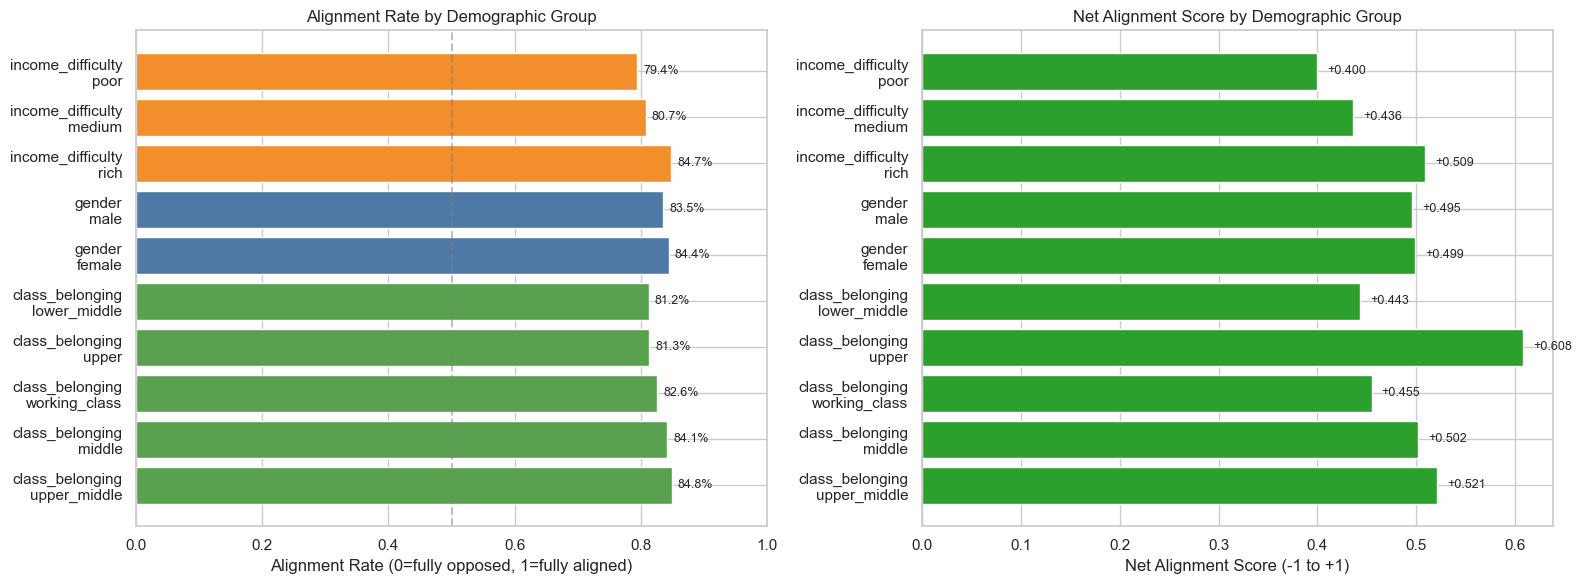

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Grouped bar chart — alignment rate by group ---
ax1 = axes[0]
plot_data = agg.copy()
plot_data["label"] = (
    plot_data["demographic_type"] + "\n" + plot_data["demographic_value"]
)

colors = {
    "gender": "#4E79A7",
    "income_difficulty": "#F28E2B",
    "class_belonging": "#59A14F",
}
bar_colors = [colors.get(dt, "#999") for dt in plot_data["demographic_type"]]

bars = ax1.barh(plot_data["label"], plot_data["alignment_rate_mean"], color=bar_colors)
ax1.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5)
ax1.set_xlabel("Alignment Rate (0=fully opposed, 1=fully aligned)")
ax1.set_title("Alignment Rate by Demographic Group")
ax1.set_xlim(0, 1)
for bar, val in zip(bars, plot_data["alignment_rate_mean"]):
    ax1.text(
        val + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1%}",
        va="center",
        fontsize=9,
    )

# --- Chart 2: Diverging bar chart — net alignment score ---
ax2 = axes[1]
bar_colors_net = [
    "#2ca02c" if v >= 0 else "#d62728" for v in plot_data["net_alignment_mean"]
]
ax2.barh(plot_data["label"], plot_data["net_alignment_mean"], color=bar_colors_net)
ax2.axvline(x=0, color="gray", linestyle="-", alpha=0.5)
ax2.set_xlabel("Net Alignment Score (-1 to +1)")
ax2.set_title("Net Alignment Score by Demographic Group")
for i, (val, label) in enumerate(
    zip(plot_data["net_alignment_mean"], plot_data["label"])
):
    ax2.text(
        val + (0.01 if val >= 0 else -0.01),
        i,
        f"{val:+.3f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

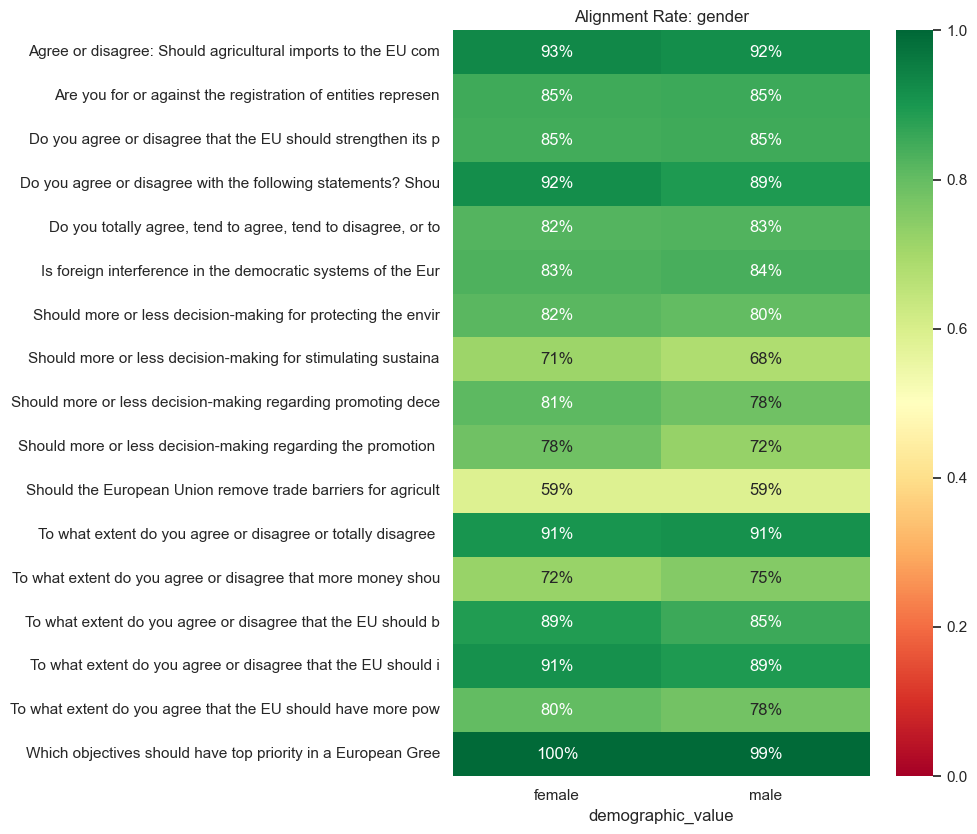

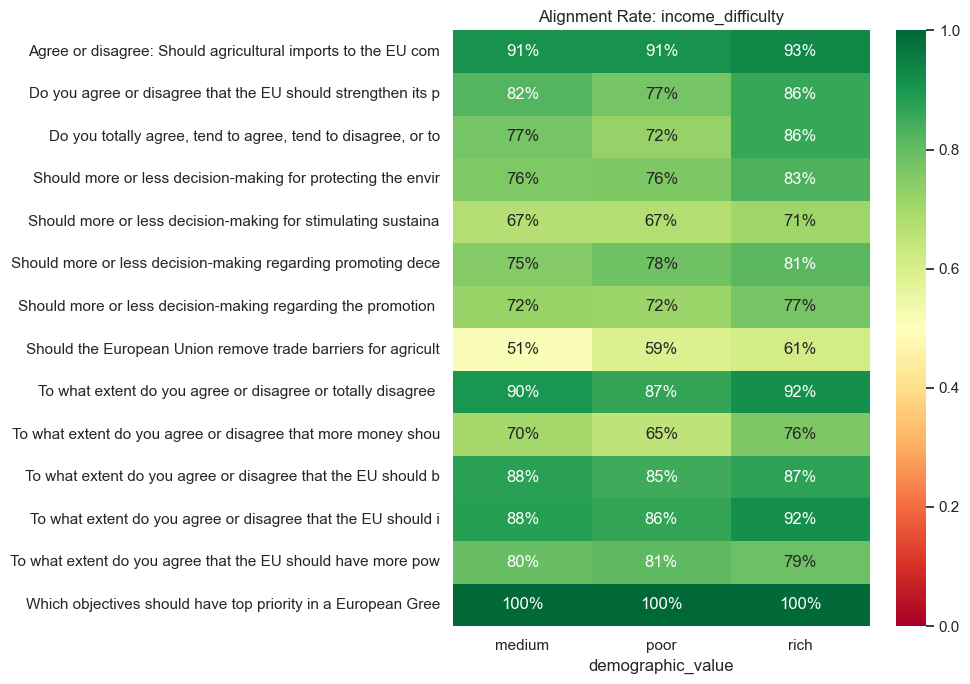

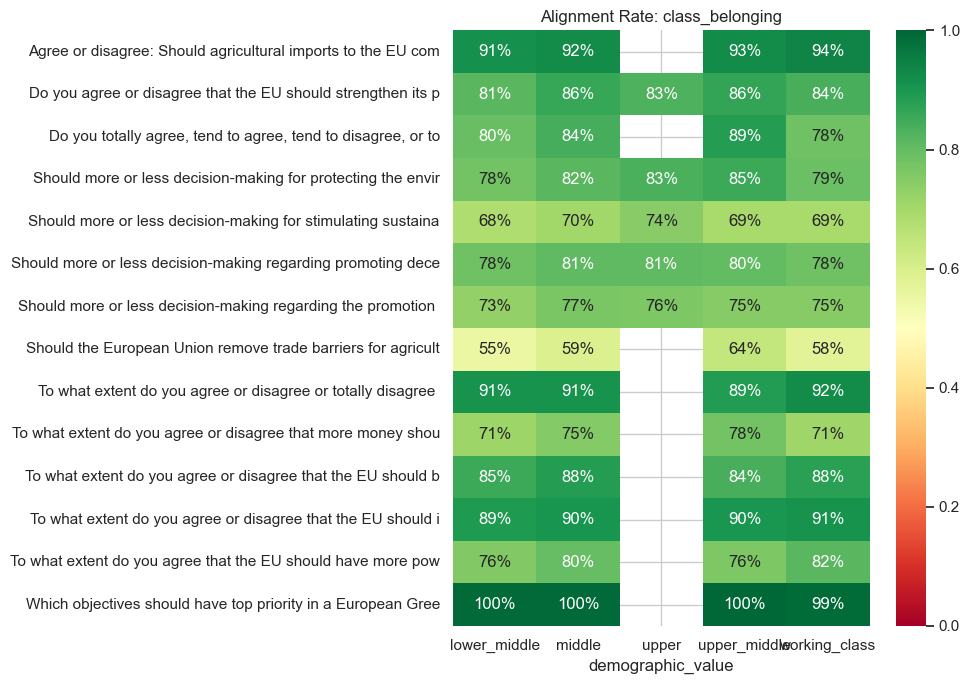

In [12]:
# --- Heatmap: per-question × demographic value alignment rate ---
# Add question text for readability
pivot_with_text = pivot.merge(
    df_matches[["match_id", "question_clean"]].drop_duplicates(),
    on="match_id",
    how="left",
)
pivot_with_text["q_label"] = (
    pivot_with_text["question_clean"].fillna(pivot_with_text["question_id"]).str[:60]
)

for demo_type in TARGET_DEMOGRAPHICS:
    subset = pivot_with_text[pivot_with_text["demographic_type"] == demo_type]
    if subset.empty:
        continue

    heatmap_data = subset.pivot_table(
        index="q_label",
        columns="demographic_value",
        values="alignment_rate",
        aggfunc="mean",
    )

    if heatmap_data.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, max(4, len(heatmap_data) * 0.5)))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".0%",
        cmap="RdYlGn",
        center=0.5,
        vmin=0,
        vmax=1,
        ax=ax,
    )
    ax.set_title(f"Alignment Rate: {demo_type}")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## 9. Key Findings Summary

**Interpretation guide:**
- **Alignment rate > 0.5**: The demographic group tends to agree with how the EU Parliament voted
- **Alignment rate < 0.5**: The demographic group tends to disagree with parliamentary votes
- **Net alignment score > 0**: More people in the group align than oppose parliament
- **Statistically significant chi-squared**: Alignment rates differ meaningfully across demographic values within a category
- **Cramer's V**: Effect size (0.1 = small, 0.3 = medium, 0.5 = large)

In [13]:
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

total_questions = pivot["question_id"].nunique()
total_alignments = len(df_alignments)
print(f"\nDataset: {total_questions} questions, {total_alignments} labelled alignments")

# Most and least aligned groups
most_aligned = agg.loc[agg["alignment_rate_mean"].idxmax()]
least_aligned = agg.loc[agg["alignment_rate_mean"].idxmin()]
print(
    f"\nMost aligned with Parliament: {most_aligned['demographic_value']} ({most_aligned['demographic_type']}) — {most_aligned['alignment_rate_mean']:.1%}"
)
print(
    f"Least aligned with Parliament: {least_aligned['demographic_value']} ({least_aligned['demographic_type']}) — {least_aligned['alignment_rate_mean']:.1%}"
)

# Statistical significance
print("\nStatistical tests:")
for demo_type, stats in stats_results.items():
    sig = "SIGNIFICANT" if stats["significant"] else "not significant"
    print(
        f"  {demo_type}: chi2={stats['chi_squared']:.1f}, p={stats['p_value']:.4f} ({sig}), Cramer's V={stats['cramers_v']:.3f}"
    )

KEY FINDINGS

Dataset: 20 questions, 178 labelled alignments

Most aligned with Parliament: upper_middle (class_belonging) — 84.8%
Least aligned with Parliament: poor (income_difficulty) — 79.4%

Statistical tests:
  gender: chi2=80.7, p=0.0000 (SIGNIFICANT), Cramer's V=0.011
  income_difficulty: chi2=1763.6, p=0.0000 (SIGNIFICANT), Cramer's V=0.058
  class_belonging: chi2=589.8, p=0.0000 (SIGNIFICANT), Cramer's V=0.034
